# 11 Hidden State Analysis

Extract hidden trajectories from the saved checkpoints, compare their correlation structure, and study their effective dimensionality with PCA.

In [1]:
import os
from pathlib import Path

os.environ['COURSEWORK_DEVICE'] = 'cpu'

ARTIFACT_ROOT = Path('artifacts')
SEED = 20260328
PREFERRED_SAMPLE_CLASS = 'cyclic_or_reversing'


In [2]:
from IPython.display import Image, display

from Coursework3.RNO_1D_Skeleton import build_default_hidden_state_model_specs, run_hidden_state_analysis

model_specs = build_default_hidden_state_model_specs(artifact_root=ARTIFACT_ROOT)
hidden_results = run_hidden_state_analysis(
    model_specs=model_specs,
    artifact_root=ARTIFACT_ROOT,
    split_seed=SEED,
    preferred_sample_class=PREFERRED_SAMPLE_CLASS,
)

hidden_results['model_specs_df']


,label,checkpoint_path,color
0,best_rnn,/Users/jackhenry/Library/CloudStorage/OneDrive...,#1f77b4
1,best_gru,/Users/jackhenry/Library/CloudStorage/OneDrive...,#2ca02c
2,best_lstm,/Users/jackhenry/Library/CloudStorage/OneDrive...,#d62728
3,baseline_rno,artifacts/checkpoints/baseline_rno_from_best_g...,#9467bd
4,paper_rno_no_rate_h3,artifacts/checkpoints/09_paper_rno_no_rate_h0t...,#17becf
5,paper_rno_with_rate_h5,artifacts/checkpoints/09_paper_rno_with_rate_h...,#ff7f0e


In [3]:
hidden_results['sample_metadata_df']


,sample_index,max_abs_rate,mean_abs_rate,turning_points,hold_fraction,positive_fraction,negative_fraction,net_change,total_variation,variation_ratio,strain_min,strain_max,strain_range,base_label,loading_class,loading_class_label
3,3,0.630498,0.209374,2,0.009,0.749,0.216,0.073527,0.209374,2.847565,-0.026635,0.114816,0.141451,cyclic_or_reversing,cyclic_or_reversing,Cyclic / reversing


In [4]:
hidden_results['geometry_summary_df']


,model_label,checkpoint_path,hidden_size,active_hidden_size,dominant_pc_ratio,pcs_for_90,pcs_for_95,pcs_for_99,mean_abs_offdiag_corr,max_abs_offdiag_corr,n_pairs_abs_corr_ge_095,test_relative_l2,test_rmse,test_r2,prediction_path,hidden_path
0,best_gru,/Users/jackhenry/Library/CloudStorage/OneDrive...,40,40,0.869780,2,2,2,0.680617,0.998940,348,0.003717,0.001260,0.999986,artifacts/predictions/11_best_gru_predictions.npz,artifacts/predictions/11_best_gru_hidden.npz
1,baseline_rno,artifacts/checkpoints/baseline_rno_from_best_g...,40,40,0.729905,2,2,2,0.580838,0.999915,184,0.008462,0.002868,0.999928,artifacts/predictions/11_baseline_rno_predicti...,artifacts/predictions/11_baseline_rno_hidden.npz
2,paper_rno_with_rate_h5,artifacts/checkpoints/09_paper_rno_with_rate_h...,5,5,0.606742,2,2,2,0.552830,0.994888,4,0.008859,0.003003,0.999921,artifacts/predictions/11_paper_rno_with_rate_h...,artifacts/predictions/11_paper_rno_with_rate_h...
3,best_rnn,/Users/jackhenry/Library/CloudStorage/OneDrive...,48,48,0.888455,2,2,3,0.670907,0.999355,356,0.008912,0.003021,0.999920,artifacts/predictions/11_best_rnn_predictions.npz,artifacts/predictions/11_best_rnn_hidden.npz
4,best_lstm,/Users/jackhenry/Library/CloudStorage/OneDrive...,24,24,0.851888,2,3,5,0.609276,0.993991,50,0.009123,0.003093,0.999916,artifacts/predictions/11_best_lstm_predictions...,artifacts/predictions/11_best_lstm_hidden.npz
5,paper_rno_no_rate_h3,artifacts/checkpoints/09_paper_rno_no_rate_h0t...,3,3,0.697801,2,2,2,0.612634,0.917114,0,0.477525,0.161878,0.769701,artifacts/predictions/11_paper_rno_no_rate_h3_...,artifacts/predictions/11_paper_rno_no_rate_h3_...


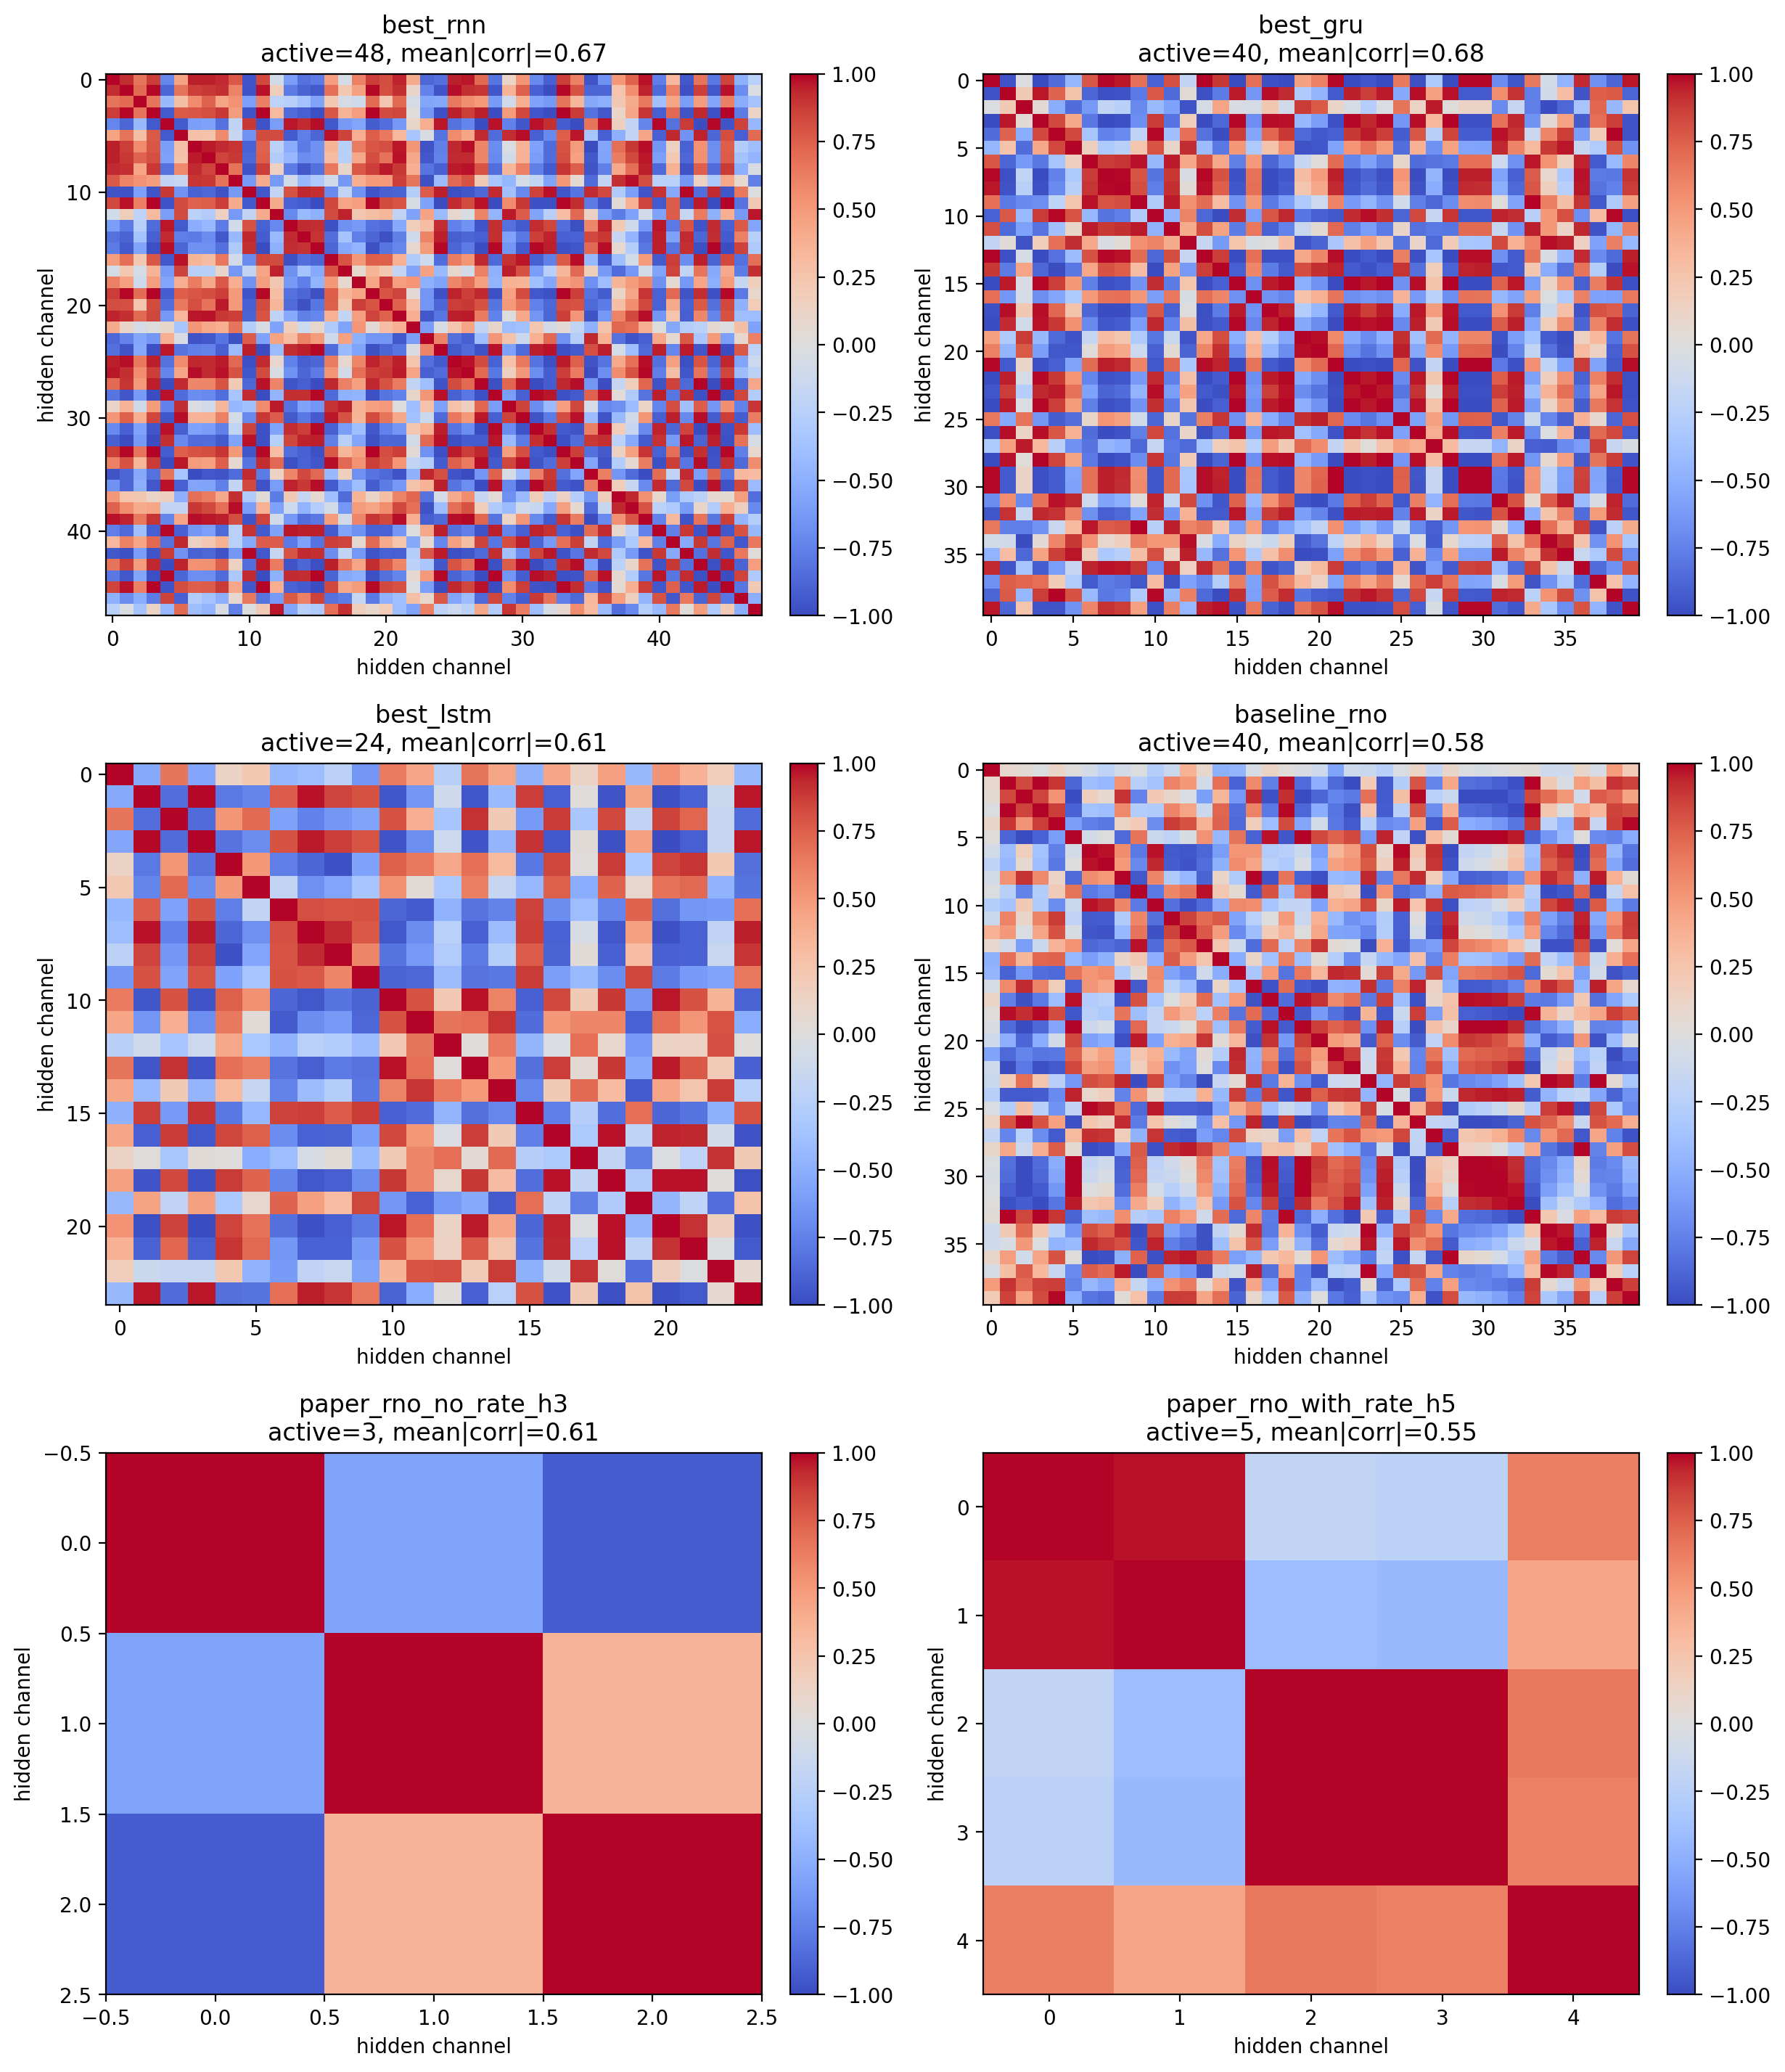

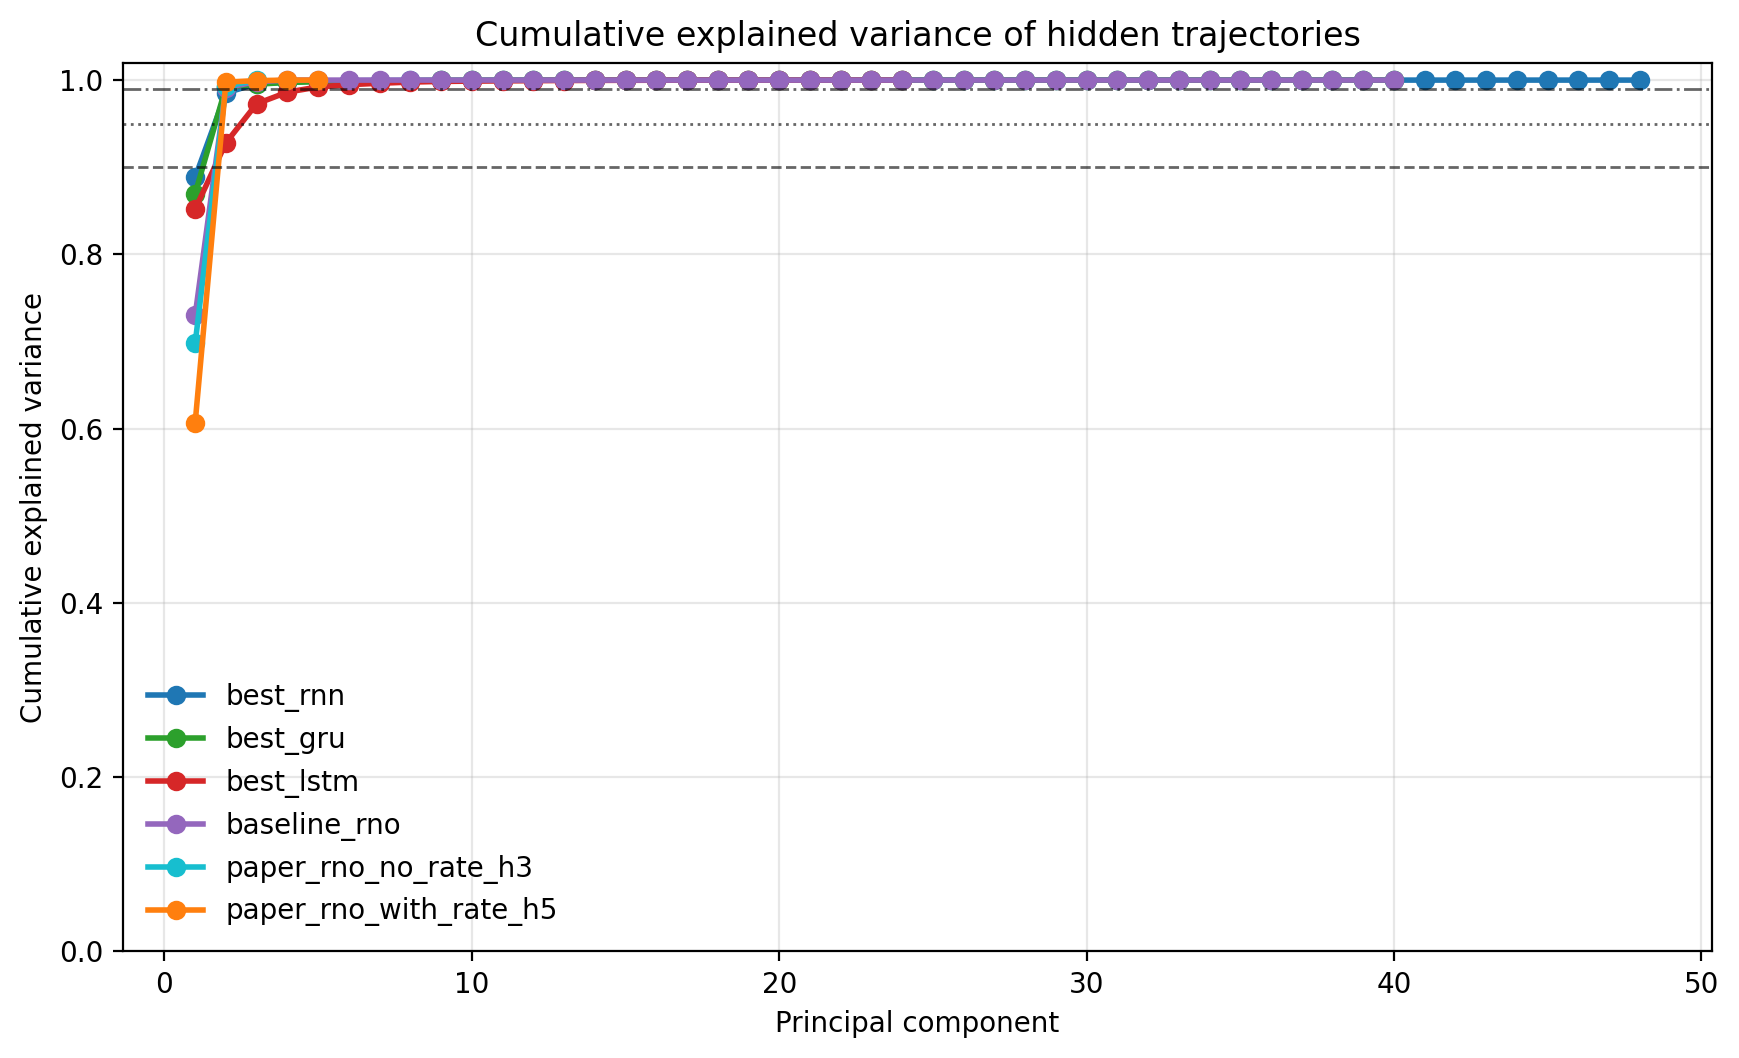

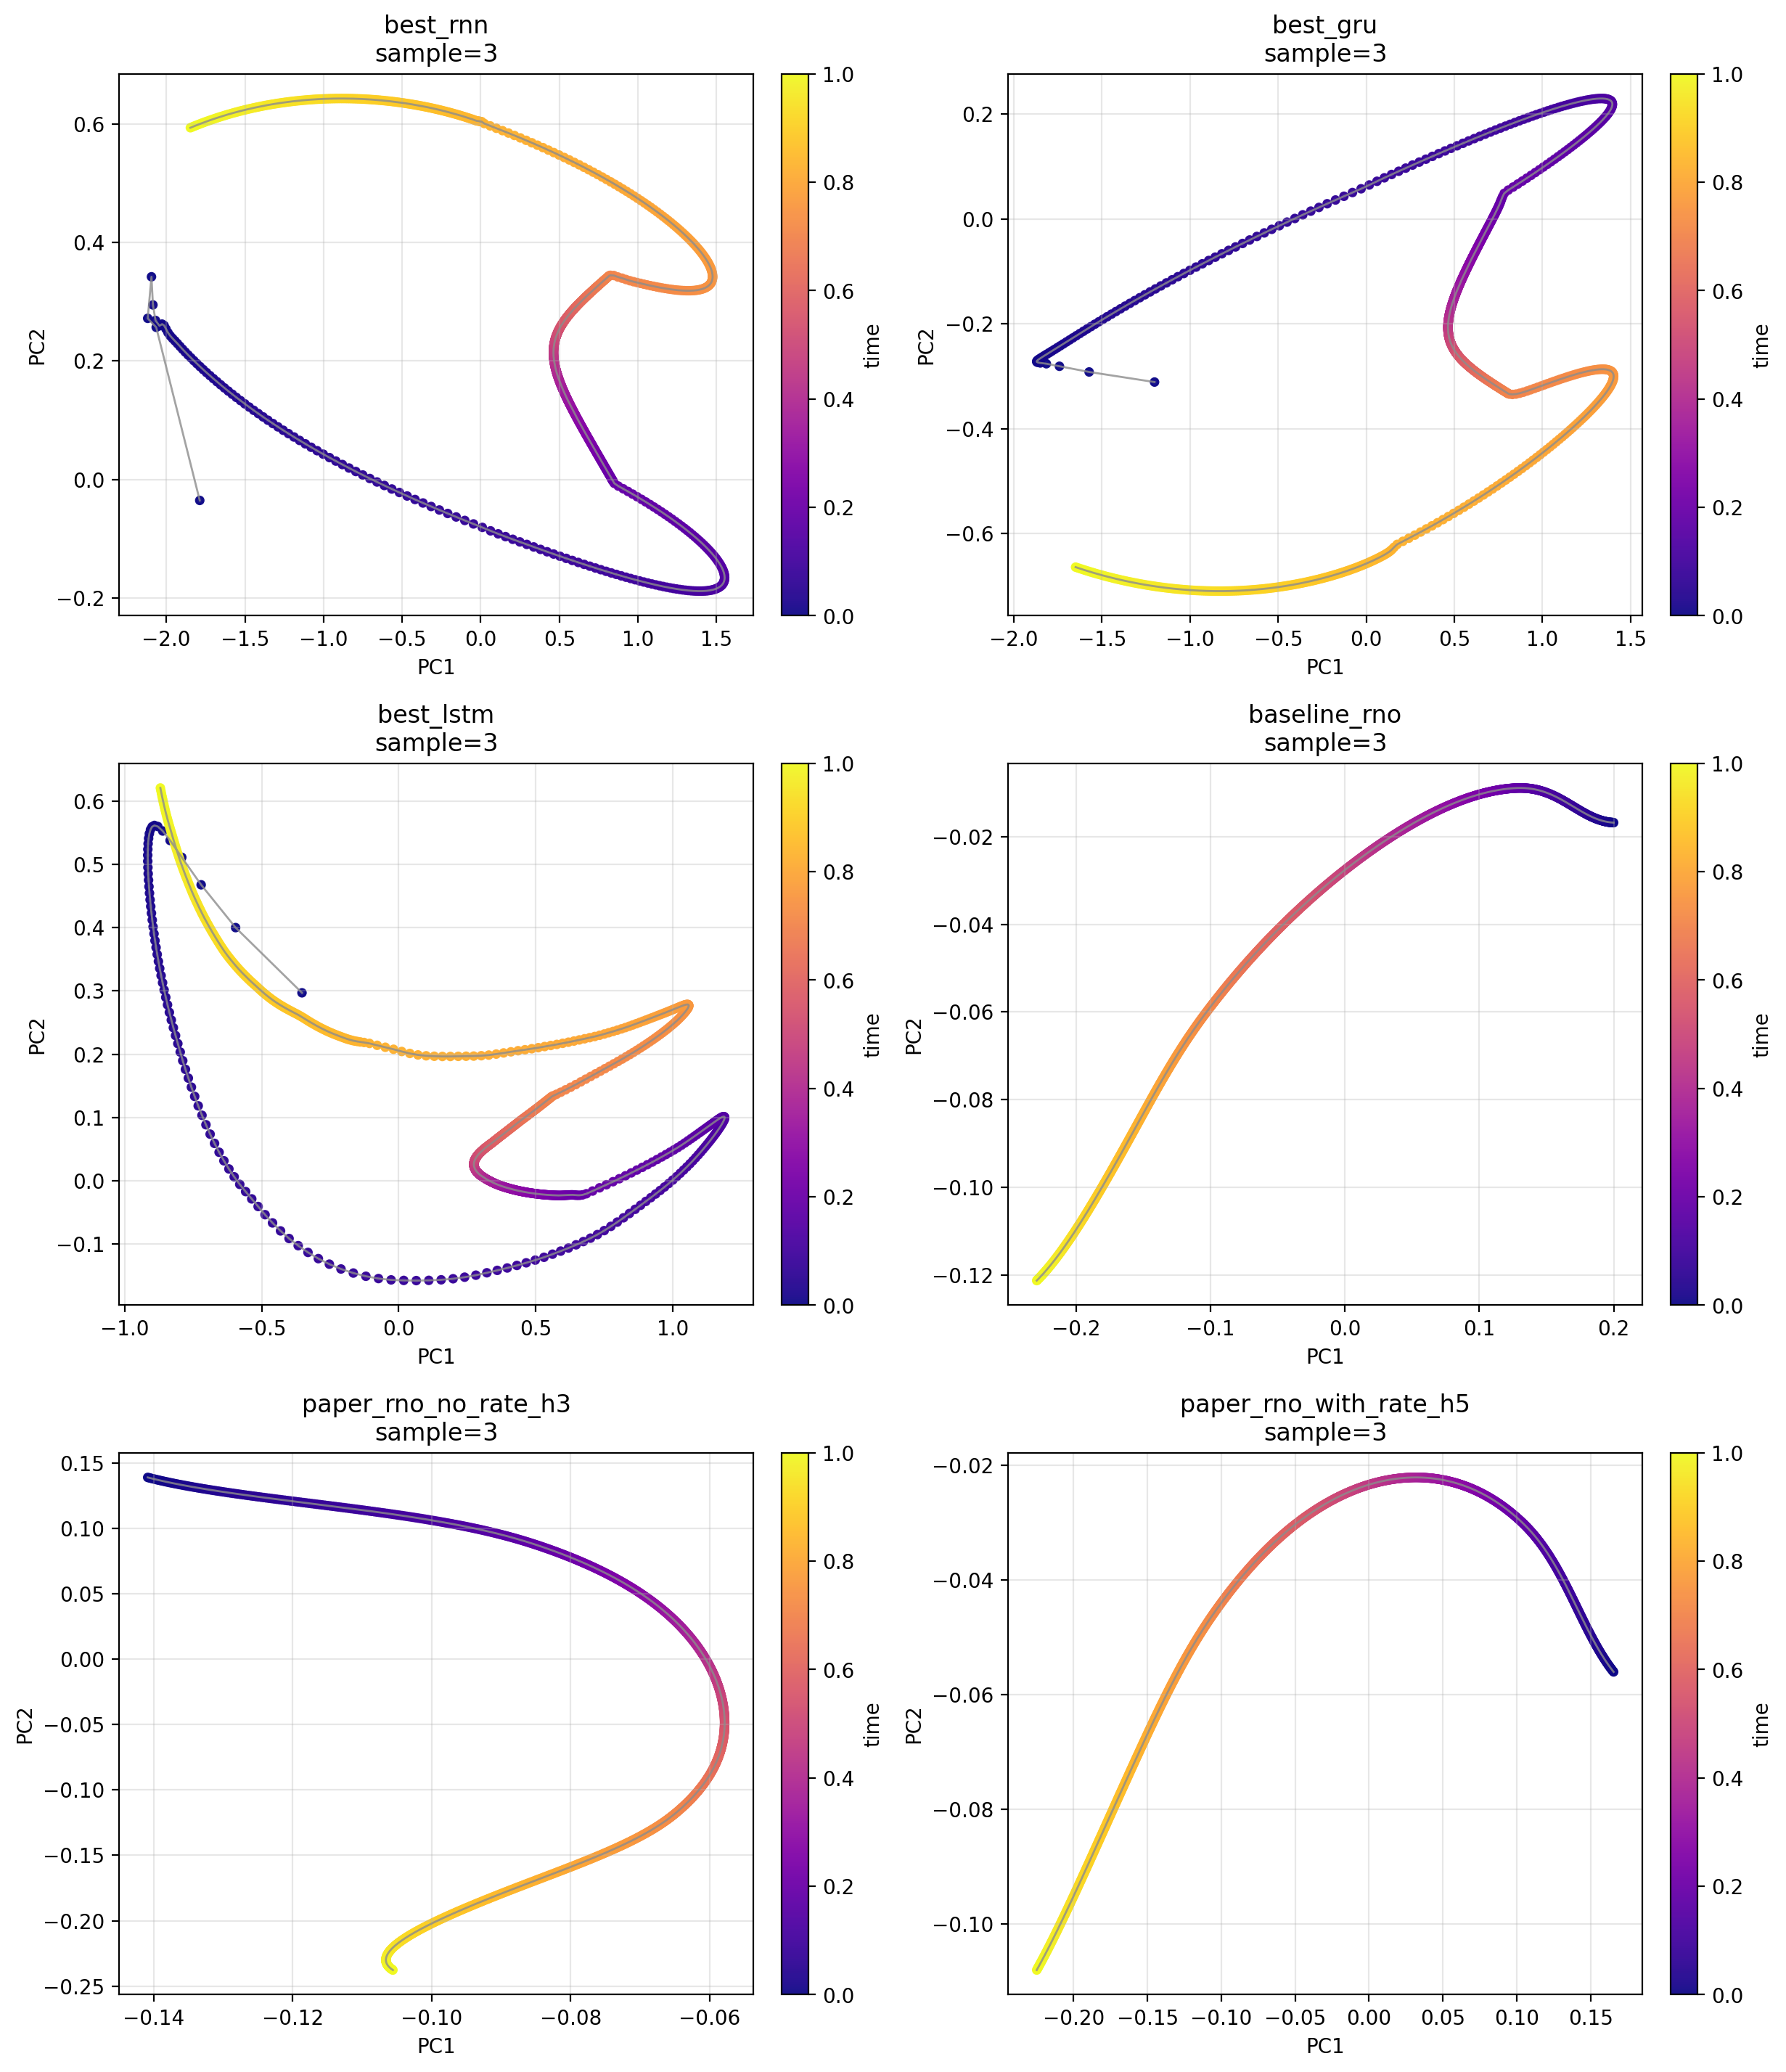

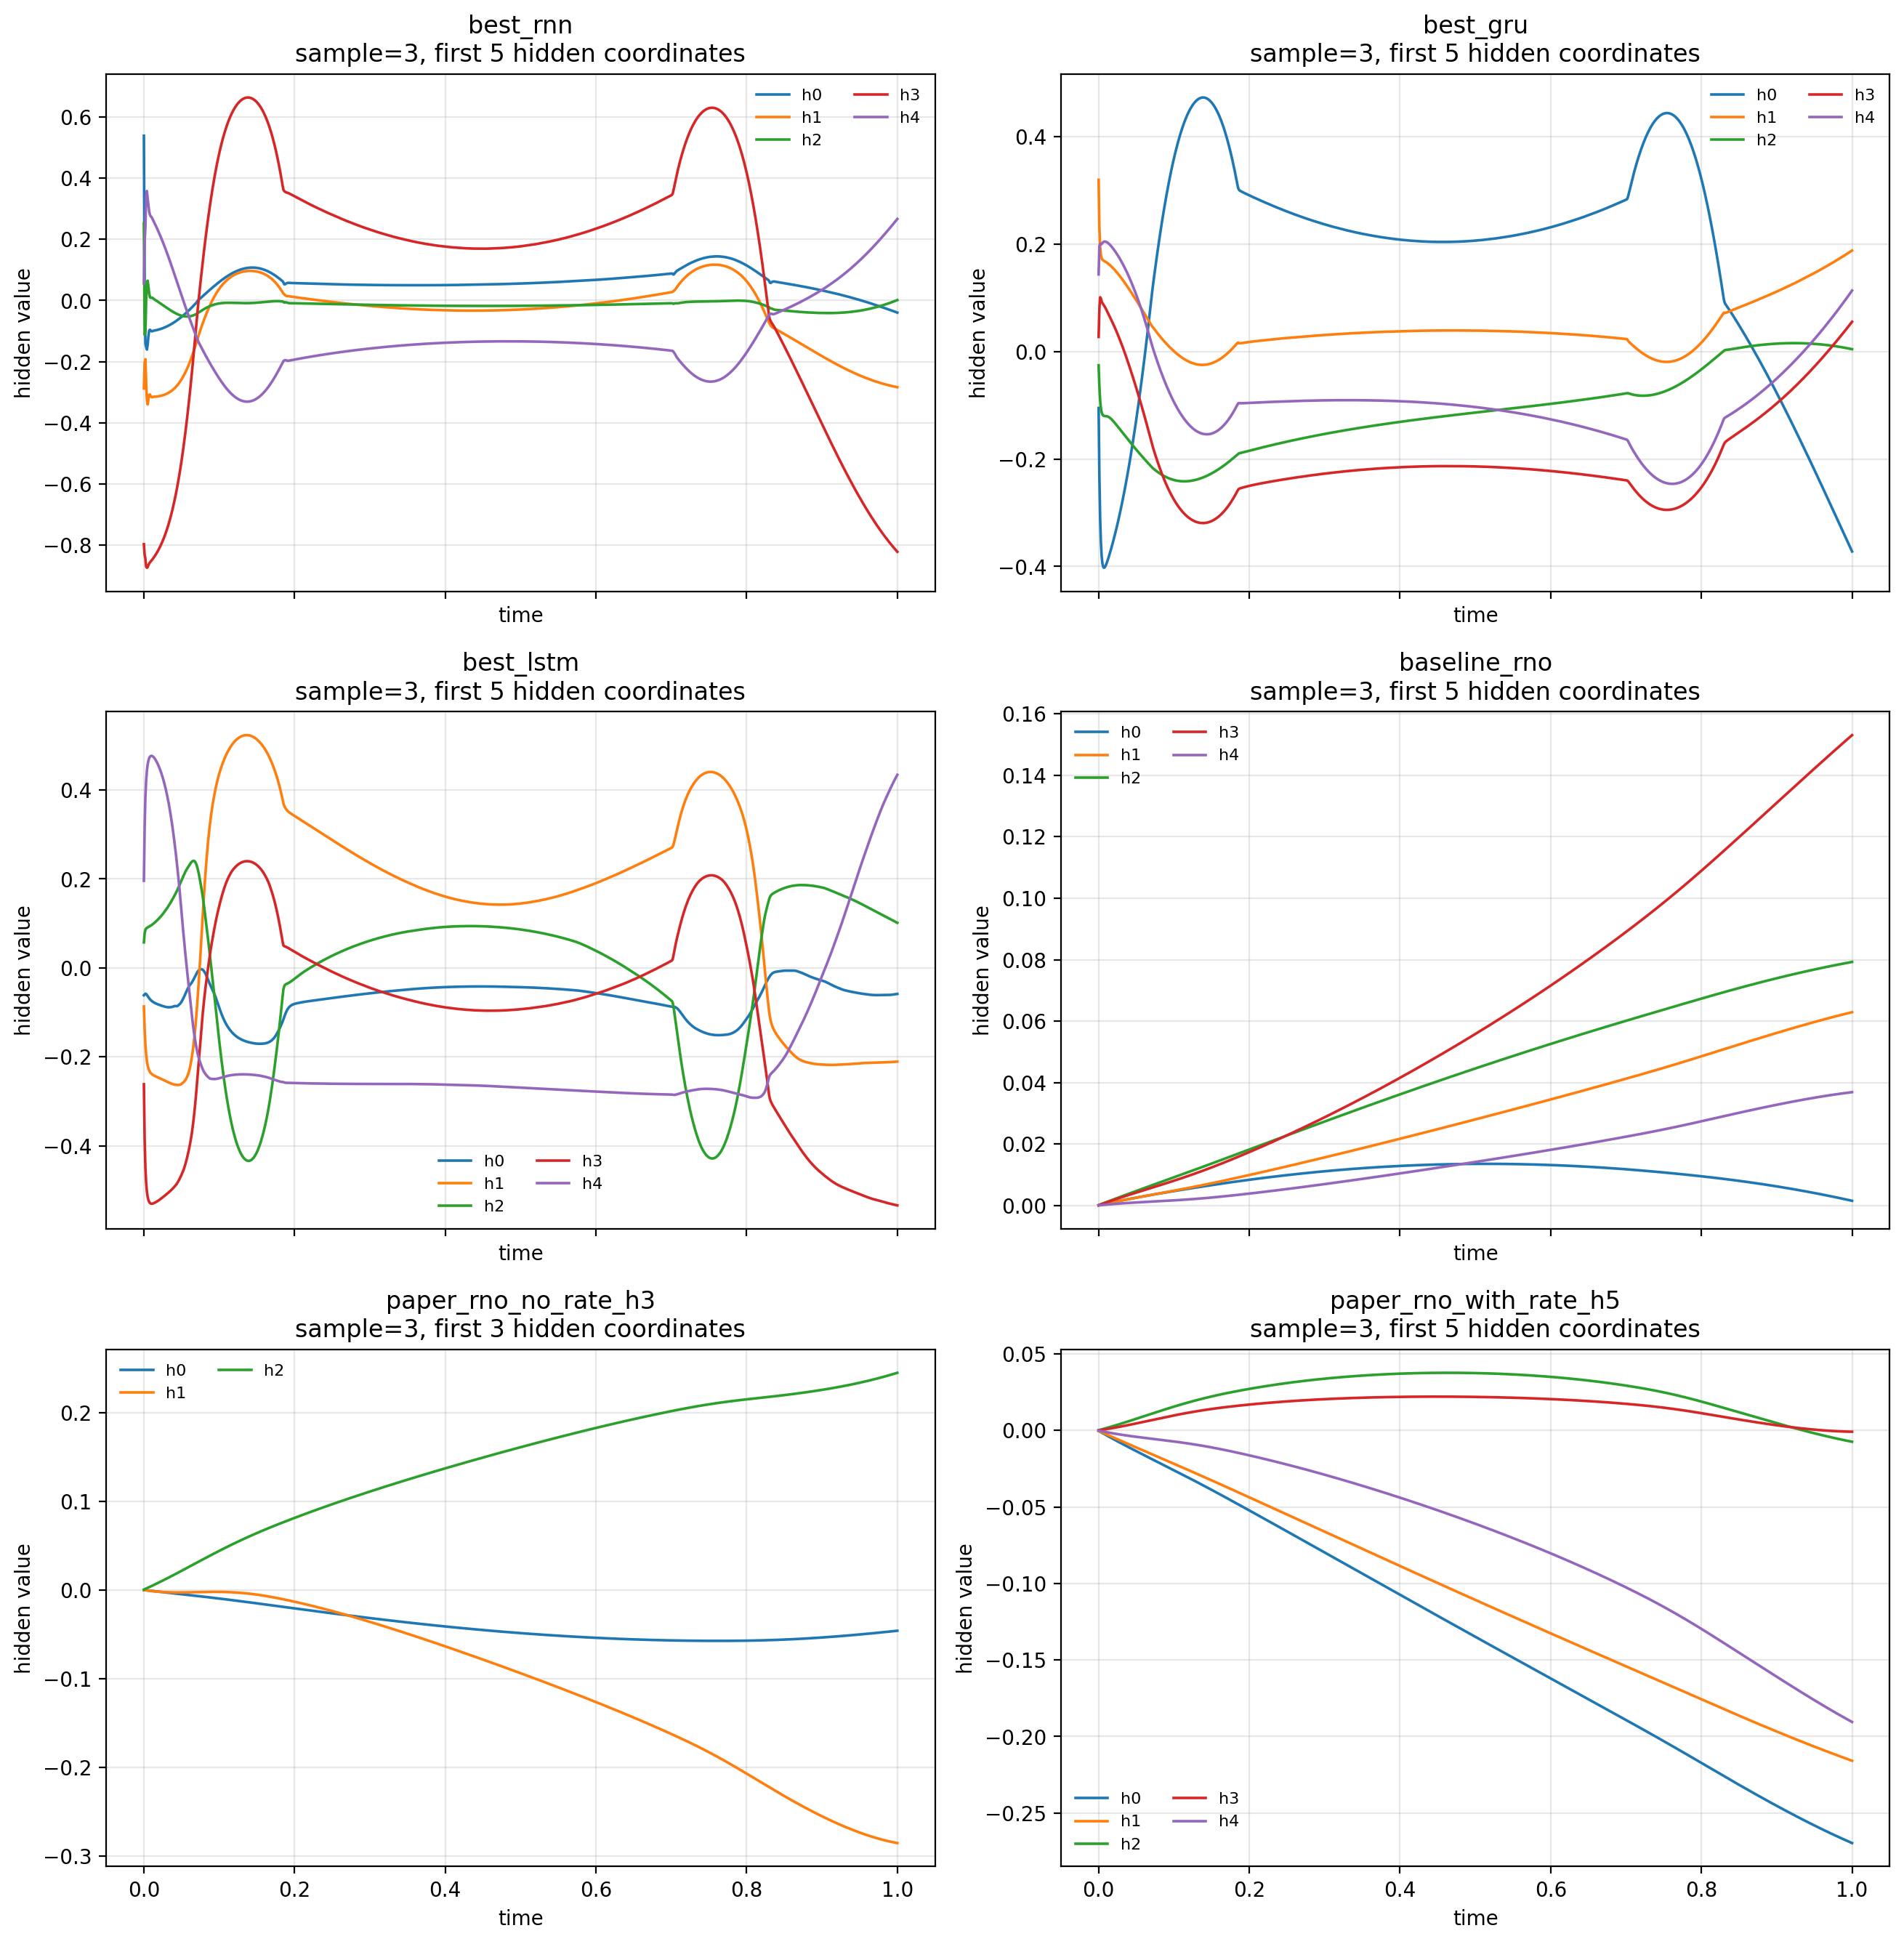

In [5]:
for figure_path in [
    hidden_results['correlation_plot_path'],
    hidden_results['pca_variance_plot_path'],
    hidden_results['pca_trajectory_plot_path'],
    hidden_results['time_trace_plot_path'],
]:
    display(Image(filename=str(figure_path)))


In [6]:
hidden_results


{'model_specs_df':                     label                                    checkpoint_path  \
 0                best_rnn  /Users/jackhenry/Library/CloudStorage/OneDrive...   
 1                best_gru  /Users/jackhenry/Library/CloudStorage/OneDrive...   
 2               best_lstm  /Users/jackhenry/Library/CloudStorage/OneDrive...   
 3            baseline_rno  artifacts/checkpoints/baseline_rno_from_best_g...   
 4    paper_rno_no_rate_h3  artifacts/checkpoints/09_paper_rno_no_rate_h0t...   
 5  paper_rno_with_rate_h5  artifacts/checkpoints/09_paper_rno_with_rate_h...   
 
      color  
 0  #1f77b4  
 1  #2ca02c  
 2  #d62728  
 3  #9467bd  
 4  #17becf  
 5  #ff7f0e  ,
 'class_df':     sample_index  max_abs_rate  mean_abs_rate  turning_points  hold_fraction  \
 0              0      0.563815       0.207803               2          0.085   
 1              1      0.540555       0.208602               2          0.025   
 2              2      0.706226       0.205616             